# Compare Prediction vs Ground Truth

This notebook compares `prediction.nc` from `easy_inference` with ground-truth NetCDF files and computes:
- overall metrics (`MSE`, `RMSE`, `MAE`, `bias`, `max_abs_error`)
- per-channel metrics
- per-step metrics
- visual comparison for one channel/timestamp

It does not depend on `inference/` code.

In [ ]:
# %cd /Users/rlal/nasa_impact/Surya

/Users/rlal/nasa_impact/Surya


In [7]:
import json
from datetime import datetime
from pathlib import Path

import h5netcdf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

plt.rcParams["figure.dpi"] = 120

PREDICTION_NC = Path("easy_inference/outputs_20141023_60min/prediction.nc")
VALIDATION_DATA_DIR = Path("data/Surya-1.0_validation_data_20141023_60min")
OUTPUT_DIR = Path("easy_inference/outputs_20141023_60min/metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Prediction file   : {PREDICTION_NC.resolve()}")
print(f"Validation dir    : {VALIDATION_DATA_DIR.resolve()}")
print(f"Metrics output dir: {OUTPUT_DIR.resolve()}")

Prediction file   : /Users/rlal/nasa_impact/Surya/easy_inference/outputs_20141023_60min/prediction.nc
Validation dir    : /Users/rlal/nasa_impact/Surya/data/Surya-1.0_validation_data_20141023_60min
Metrics output dir: /Users/rlal/nasa_impact/Surya/easy_inference/outputs_20141023_60min/metrics


In [8]:
def _dim_size(dim_obj):
    return int(dim_obj.size) if hasattr(dim_obj, "size") else int(dim_obj)


def decode_fixed_width(char_array: np.ndarray) -> np.ndarray:
    arr = np.asarray(char_array)
    if arr.dtype.kind != "S" or arr.dtype.itemsize != 1 or arr.ndim < 1:
        raise ValueError(f"Expected fixed-width S1 char array, got dtype={arr.dtype} shape={arr.shape}")

    width = arr.shape[-1]
    flat = arr.reshape(-1, width)
    out = []
    for row in flat:
        text = b"".join(row.tolist()).decode("utf-8", errors="ignore").rstrip("\x00")
        out.append(text)
    return np.asarray(out, dtype=object).reshape(arr.shape[:-1])


def timestamp_to_filename(ts_text: str) -> str:
    # prediction timestamp format is typically YYYY-MM-DDTHH:MM:SS
    dt = datetime.strptime(ts_text, "%Y-%m-%dT%H:%M:%S")
    return dt.strftime("%Y%m%d_%H%M.nc")


def empty_stats() -> dict:
    return {"sse": 0.0, "sae": 0.0, "sum_err": 0.0, "max_abs": 0.0, "count": 0}


def update_stats(stats: dict, diff: np.ndarray) -> None:
    abs_diff = np.abs(diff)
    stats["sse"] += float(np.sum(diff * diff, dtype=np.float64))
    stats["sae"] += float(np.sum(abs_diff, dtype=np.float64))
    stats["sum_err"] += float(np.sum(diff, dtype=np.float64))
    stats["max_abs"] = float(max(stats["max_abs"], float(np.max(abs_diff))))
    stats["count"] += int(diff.size)


def finalize_stats(stats: dict) -> dict:
    if stats["count"] == 0:
        return {"mse": np.nan, "rmse": np.nan, "mae": np.nan, "bias": np.nan, "max_abs_error": np.nan}
    mse = stats["sse"] / stats["count"]
    return {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(stats["sae"] / stats["count"]),
        "bias": float(stats["sum_err"] / stats["count"]),
        "max_abs_error": float(stats["max_abs"]),
    }

In [9]:
if not PREDICTION_NC.exists():
    raise FileNotFoundError(f"Missing prediction file: {PREDICTION_NC}")
if not VALIDATION_DATA_DIR.exists():
    raise FileNotFoundError(f"Missing validation data dir: {VALIDATION_DATA_DIR}")

with h5netcdf.File(PREDICTION_NC, "r") as pred_file:
    sample_capacity = _dim_size(pred_file.dimensions["sample"])
    samples_written = int(pred_file.attrs.get("samples_written", sample_capacity))
    image_height = _dim_size(pred_file.dimensions["y"])
    image_width = _dim_size(pred_file.dimensions["x"])

    channels = decode_fixed_width(pred_file.variables["channel_names"][:]).tolist()
    sample_ids = np.asarray(pred_file.variables["sample_id"][:samples_written], dtype=np.int64)
    prediction_timestamps = decode_fixed_width(
        pred_file.variables["prediction_timestamps"][:samples_written, :, :]
    )

summary_df = pd.DataFrame(
    {
        "samples_written": [samples_written],
        "prediction_steps": [prediction_timestamps.shape[1]],
        "channels": [len(channels)],
        "image_height": [image_height],
        "image_width": [image_width],
    }
)
display(summary_df)
print("Channels:", channels)
print("Sample IDs:", sample_ids.tolist())

,samples_written,prediction_steps,channels,image_height,image_width
0,1,3,13,4096,4096


Channels: ['aia94', 'aia131', 'aia171', 'aia193', 'aia211', 'aia304', 'aia335', 'aia1600', 'hmi_m', 'hmi_bx', 'hmi_by', 'hmi_bz', 'hmi_v']
Sample IDs: [0]


In [10]:
overall_stats = empty_stats()
channel_stats = {ch: empty_stats() for ch in channels}

per_step_rows = []
per_channel_step_rows = []

with h5netcdf.File(PREDICTION_NC, "r") as pred_file:
    for sample_idx in range(samples_written):
        for step_idx, ts_text in enumerate(prediction_timestamps[sample_idx]):
            gt_file = VALIDATION_DATA_DIR / timestamp_to_filename(ts_text)
            if not gt_file.exists():
                raise FileNotFoundError(f"Missing GT file for {ts_text}: {gt_file}")

            step_stats = empty_stats()

            with xr.open_dataset(gt_file) as gt_ds:
                for channel in channels:
                    if channel not in gt_ds:
                        raise KeyError(f"Channel '{channel}' missing from {gt_file}")

                    pred_frame = np.asarray(
                        pred_file.variables[channel][sample_idx, step_idx, :, :],
                        dtype=np.float32,
                    )
                    gt_frame = np.asarray(gt_ds[channel].values, dtype=np.float32)
                    if pred_frame.shape != gt_frame.shape:
                        raise RuntimeError(
                            f"Shape mismatch for {channel} at {ts_text}: pred={pred_frame.shape} gt={gt_frame.shape}"
                        )

                    diff = pred_frame - gt_frame
                    update_stats(overall_stats, diff)
                    update_stats(step_stats, diff)
                    update_stats(channel_stats[channel], diff)

                    temp_stats = empty_stats()
                    update_stats(temp_stats, diff)
                    channel_step_metric = finalize_stats(temp_stats)
                    per_channel_step_rows.append(
                        {
                            "sample_idx": int(sample_idx),
                            "sample_id": int(sample_ids[sample_idx]),
                            "prediction_step_idx": int(step_idx),
                            "timestamp": str(ts_text),
                            "channel": channel,
                            **channel_step_metric,
                        }
                    )

            per_step_rows.append(
                {
                    "sample_idx": int(sample_idx),
                    "sample_id": int(sample_ids[sample_idx]),
                    "prediction_step_idx": int(step_idx),
                    "timestamp": str(ts_text),
                    **finalize_stats(step_stats),
                }
            )

overall_metrics = finalize_stats(overall_stats)
per_channel_df = pd.DataFrame(
    [{"channel": ch, **finalize_stats(channel_stats[ch])} for ch in channels]
).sort_values("mse")
per_step_df = pd.DataFrame(per_step_rows).sort_values(["sample_idx", "prediction_step_idx"])
per_channel_step_df = pd.DataFrame(per_channel_step_rows).sort_values(["sample_idx", "prediction_step_idx", "channel"])

overall_df = pd.DataFrame([overall_metrics])
display(overall_df)
display(per_channel_df)
display(per_step_df)

,mse,rmse,mae,bias,max_abs_error
0,5354.019011,73.171162,19.17855,-1.543747,11832.385742


,channel,mse,rmse,mae,bias,max_abs_error
0,aia94,0.548424,0.740557,0.314200,-0.015492,561.101929
6,aia335,2.510944,1.584596,0.923267,-0.057039,451.149658
1,aia131,6.578371,2.564833,1.063624,-0.042252,1258.069580
7,aia1600,223.974268,14.965770,6.963505,-0.429648,6079.697266
8,hmi_m,238.597068,15.446588,4.212467,-0.055040,880.116455
11,hmi_bz,321.596127,17.933101,4.318214,-0.082896,1257.387207
4,aia211,334.829238,18.298340,5.426113,-0.796700,3756.265869
5,aia304,462.294104,21.501026,7.188955,-0.798548,11806.338867
3,aia193,2295.728791,47.913764,15.855740,-2.826563,7995.218750
10,hmi_by,2393.004396,48.918344,27.336016,0.096741,1972.673340


,sample_idx,sample_id,prediction_step_idx,timestamp,mse,rmse,mae,bias,max_abs_error
0,0,0,0,2014-10-23T12:00:00,5311.908737,72.882843,18.518644,-1.239556,11832.385742
1,0,0,1,2014-10-23T13:00:00,5335.966241,73.047698,19.255654,-1.720512,7881.041992
2,0,0,2,2014-10-23T14:00:00,5414.182056,73.581126,19.761353,-1.671175,9163.189453


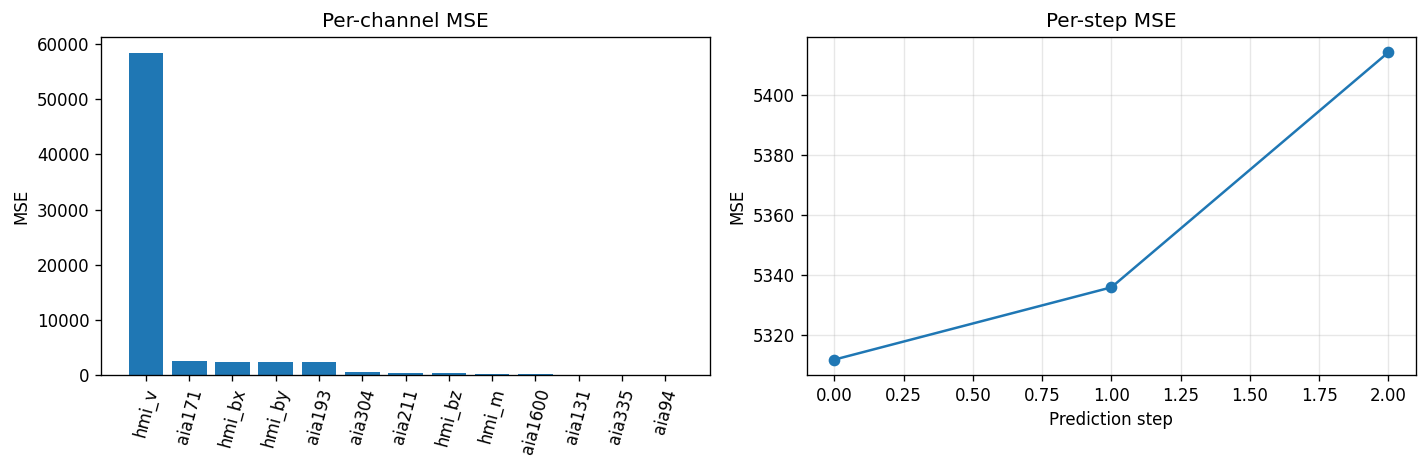

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

per_channel_plot = per_channel_df.sort_values("mse", ascending=False)
axes[0].bar(per_channel_plot["channel"], per_channel_plot["mse"])
axes[0].set_title("Per-channel MSE")
axes[0].set_ylabel("MSE")
axes[0].tick_params(axis="x", rotation=75)

axes[1].plot(per_step_df["prediction_step_idx"], per_step_df["mse"], marker="o")
axes[1].set_title("Per-step MSE")
axes[1].set_xlabel("Prediction step")
axes[1].set_ylabel("MSE")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

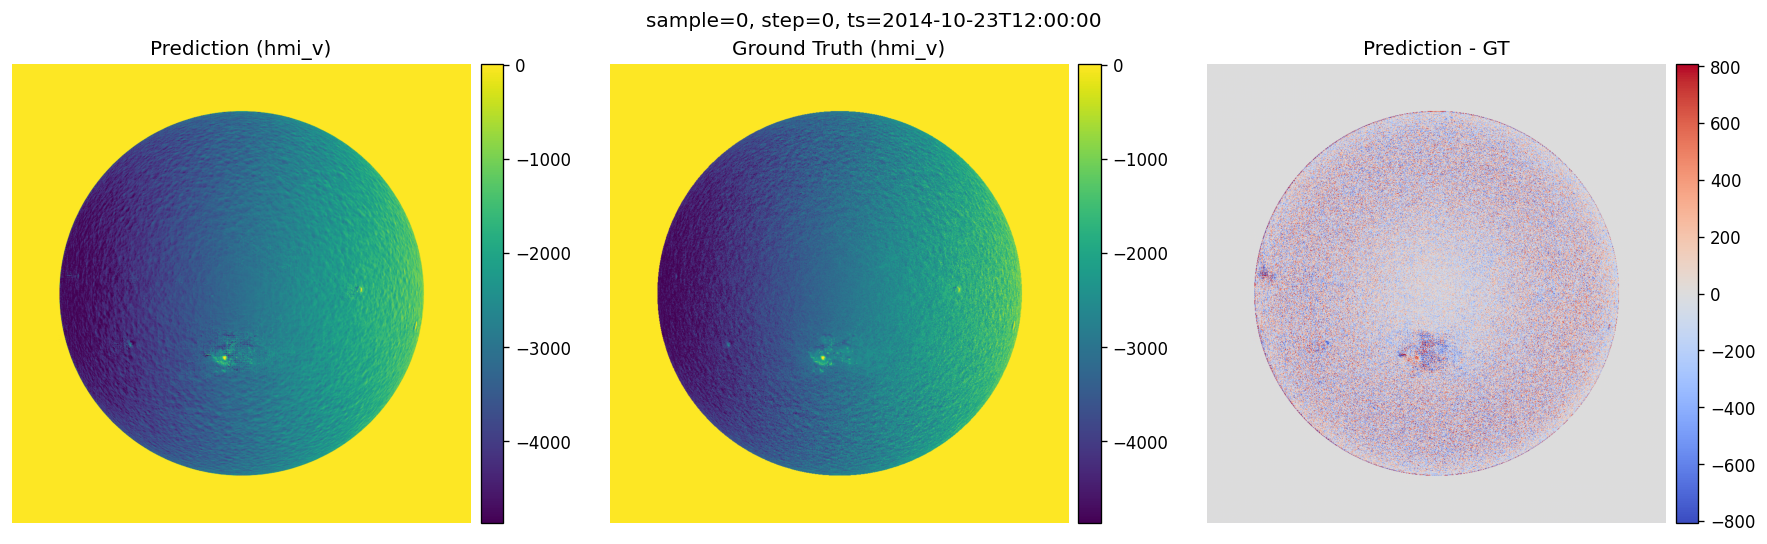

,sample_idx,step_idx,timestamp,channel,mse,rmse,mae,bias,max_abs_error
0,0,0,2014-10-23T12:00:00,hmi_v,59246.328433,243.405687,131.501696,-10.595309,11832.385742


In [16]:
# Visual comparison for one sample/step/channel
SAMPLE_IDX = 0
STEP_IDX = 0
CHANNEL = "hmi_v"
DOWNSAMPLE = 4  # for faster plotting

ts_text = str(prediction_timestamps[SAMPLE_IDX, STEP_IDX])
gt_file = VALIDATION_DATA_DIR / timestamp_to_filename(ts_text)

with h5netcdf.File(PREDICTION_NC, "r") as pred_file:
    pred_frame = np.asarray(pred_file.variables[CHANNEL][SAMPLE_IDX, STEP_IDX, :, :], dtype=np.float32)
with xr.open_dataset(gt_file) as gt_ds:
    gt_frame = np.asarray(gt_ds[CHANNEL].values, dtype=np.float32)

diff = pred_frame - gt_frame
frame_mse = float(np.mean(diff * diff, dtype=np.float64))
frame_mae = float(np.mean(np.abs(diff), dtype=np.float64))
frame_rmse = float(np.sqrt(frame_mse))
frame_bias = float(np.mean(diff, dtype=np.float64))
frame_max_abs = float(np.max(np.abs(diff)))

pred_plot = pred_frame[::DOWNSAMPLE, ::DOWNSAMPLE]
gt_plot = gt_frame[::DOWNSAMPLE, ::DOWNSAMPLE]
diff_plot = diff[::DOWNSAMPLE, ::DOWNSAMPLE]

vmin, vmax = np.percentile(np.concatenate([pred_plot.ravel(), gt_plot.ravel()]), [1, 99])
dmax = np.percentile(np.abs(diff_plot), 99)
dmax = max(float(dmax), 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].imshow(pred_plot, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Prediction ({CHANNEL})")
axes[0].axis("off")

im1 = axes[1].imshow(gt_plot, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Ground Truth ({CHANNEL})")
axes[1].axis("off")

im2 = axes[2].imshow(diff_plot, origin="lower", cmap="coolwarm", vmin=-dmax, vmax=dmax)
axes[2].set_title("Prediction - GT")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
fig.suptitle(f"sample={SAMPLE_IDX}, step={STEP_IDX}, ts={ts_text}")
plt.tight_layout()
plt.show()

pd.DataFrame([
    {
        "sample_idx": SAMPLE_IDX,
        "step_idx": STEP_IDX,
        "timestamp": ts_text,
        "channel": CHANNEL,
        "mse": frame_mse,
        "rmse": frame_rmse,
        "mae": frame_mae,
        "bias": frame_bias,
        "max_abs_error": frame_max_abs,
    }
])

In [ ]:
run_tag = datetime.utcnow().strftime("%Y%m%d_%H%M%S")

per_channel_csv = OUTPUT_DIR / f"per_channel_metrics_{run_tag}.csv"
per_step_csv = OUTPUT_DIR / f"per_step_metrics_{run_tag}.csv"
per_channel_step_csv = OUTPUT_DIR / f"per_channel_step_metrics_{run_tag}.csv"
summary_json = OUTPUT_DIR / f"metrics_summary_{run_tag}.json"

per_channel_df.to_csv(per_channel_csv, index=False)
per_step_df.to_csv(per_step_csv, index=False)
per_channel_step_df.to_csv(per_channel_step_csv, index=False)

summary_payload = {
    "prediction_nc": str(PREDICTION_NC.resolve()),
    "validation_data_dir": str(VALIDATION_DATA_DIR.resolve()),
    "samples_written": int(samples_written),
    "channels": channels,
    "overall": overall_metrics,
}
summary_json.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")

print(f"Saved: {per_channel_csv}")
print(f"Saved: {per_step_csv}")
print(f"Saved: {per_channel_step_csv}")
print(f"Saved: {summary_json}")